In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('max_columns',1000)


In [2]:
df =pd.read_excel("Kopya SCM Dataset.xlsx")

In [3]:
df.shape

(999, 25)

In [4]:
df.columns

Index(['Company Name', 'Industry', 'Country', 'SCM Practices',
       'Supplier Count', 'Inventory Turnover Ratio', 'Lead Time (days)',
       'Order Fulfillment Rate (%)', 'Customer Satisfaction (%)',
       'Technology Utilized', 'Environmental Impact Score',
       'Supply Chain Agility', 'Supplier Lead Time Variability (days)',
       'Inventory Accuracy (%)', 'Transportation Cost Efficiency (%)',
       'Supply Chain Integration Level', 'Sustainability Practices',
       'Supply Chain Complexity Index', 'Cost of Goods Sold (COGS)',
       'Operational Efficiency Score', 'Revenue Growth Rate out of (15)',
       'Supply Chain Risk (%)', 'Supplier Collaboration Level',
       'Supply Chain Resilience Score', 'Supplier Relationship Score'],
      dtype='object')

In [5]:
#fixed the column names
d = {}

df = df.rename(columns = {'Company Name': 'Company_Name',
    'SCM Practices': 'SCM_Practices',
    'Supplier Count': 'Supplier_Count',
    'Inventory Turnover Ratio': 'Inventory_Turnover_Ratio',
    'Lead Time (days)': 'Lead_Time_(days)',
    'Order Fulfillment Rate (%)': 'Order_Fulfillment_Rate_(%)',
    'Customer Satisfaction (%)': 'Customer_Satisfaction_(%)',
    'Technology Utilized': 'Technology_Utilized',
    'Environmental Impact Score': 'Environmental_Impact_Score',
    'Supply Chain Agility': 'Supply_Chain_Agility',
    'Supplier Lead Time Variability (days)': 'Supplier_Lead_Time_Variability_(days)',
    'Inventory Accuracy (%)': 'Inventory_Accuracy_(%)',
    'Transportation Cost Efficiency (%)': 'Transportation_Cost_Efficiency_(%)',
    'Supply Chain Integration Level': 'Supply_Chain_Integration_Level',
    'Sustainability Practices': 'Sustainability_Practices',
    'Supply Chain Complexity Index': 'Supply_Chain_Complexity_Index',
    'Cost of Goods Sold (COGS)': 'COGS_Billion',
    'Operational Efficiency Score': 'Operational_Efficiency_Score',
    'Revenue Growth Rate out of (15)': 'Revenue_Growth_Rate_out_of_(15)',
    'Supply Chain Risk (%)': 'Supply_Chain_Risk_(%)',
    'Supplier Collaboration Level': 'Supplier_Collaboration_Level',
    'Supply Chain Resilience Score': 'Supply_Chain_Resilience_Score',
    'Supplier Relationship Score': 'Supplier_Relationship_Score'})
                             

In [6]:
df.head(n=5)

,Company_Name,Industry,Country,SCM_Practices,Supplier_Count,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Environmental_Impact_Score,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Sustainability_Practices,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,1300000,8.2,2,98,92,"AI, Robotics, Blockchain",80.0,High,1,99,88,High,Advanced,High,"$1,500B",85,20,5,High,90,85
1,Informatica,Software & Data Management,United States,Just-In-Time,1300000,8.2,2,98,92,"AI, Robotics, Blockchain",80.0,High,1,99,88,High,Advanced,High,"$1,500B",85,20,5,High,90,85
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,1300000,5.8,2,98,89,"AI, Robotics, Blockchain",NaN,High,1,99,88,High,Advanced,High,"$1,500B",85,20,5,High,90,85
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,1300000,5.5,2,98,89,"AI, Robotics, Blockchain",NaN,High,1,99,88,High,Advanced,High,"$1,500B",85,20,5,High,90,85
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,1300000,6.0,10,92,85,"ERP, AI, Blockchain",NaN,High,2,97,85,High,Advanced,Medium,$800B,85,11,8,High,88,85


In [7]:
df[["Technology_Utilized"]].value_counts()

Technology_Utilized     
ERP, AI, Blockchain         697
ERP, AI, Robotics           157
AI, ERP, Blockchain          68
ERP, JIT, Robotics           44
AI, Robotics, Blockchain     33
dtype: int64

In [8]:
df[df["Technology_Utilized"] == "AI, ERP, Blockchain"].head()

,Company_Name,Industry,Country,SCM_Practices,Supplier_Count,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Environmental_Impact_Score,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Sustainability_Practices,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
13,Paradeep Phosphates Limited,Fertilizer Manufacturing,India,Lean Manufacturing,1300000,4.0,4,95,90,"AI, ERP, Blockchain",NaN,High,1,98,88,High,Advanced,High,$300B,80,12,5,High,90,85
15,Nufarm Limited,Crop Protection (Agricultural Chemicals),Australia,Efficient Consumer Response,1300000,7.7,4,95,90,"AI, ERP, Blockchain",NaN,High,1,98,88,High,Advanced,High,$300B,85,12,5,High,90,85
20,Dragon Steel Corporation,Steel Manufacturing,Taiwan,Lean Manufacturing,1300000,5.0,7,98,87,"AI, ERP, Blockchain",NaN,High,1,98,92,High,Advanced,High,$1500B,81,12,3,High,95,90
32,Domo,Business Intelligence & Analytics Software,United States,Cross-Docking,100000,8.3,2,98,90,"AI, ERP, Blockchain",75.0,High,1,98,90,High,Advanced,High,$500B,80,12,5,High,90,85
33,NextGen Healthcare,Healthcare Information Technology (HCIT),United States,Cross-Docking,100000,7.5,2,98,90,"AI, ERP, Blockchain",NaN,High,1,98,90,High,Advanced,High,$500B,80,12,5,High,90,85


In [9]:
#fixed orders of values in Technology_Utilized column
new_value = "ERP, AI, Blockchain"
df.loc[df["Technology_Utilized"] == "AI, ERP, Blockchain","Technology_Utilized"]= new_value


In [10]:
df[["Technology_Utilized"]].value_counts()

Technology_Utilized     
ERP, AI, Blockchain         765
ERP, AI, Robotics           157
ERP, JIT, Robotics           44
AI, Robotics, Blockchain     33
dtype: int64

In [11]:
df.dtypes 

Company_Name                              object
Industry                                  object
Country                                   object
SCM_Practices                             object
Supplier_Count                             int64
Inventory_Turnover_Ratio                 float64
Lead_Time_(days)                           int64
Order_Fulfillment_Rate_(%)                 int64
Customer_Satisfaction_(%)                  int64
Technology_Utilized                       object
Environmental_Impact_Score               float64
Supply_Chain_Agility                      object
Supplier_Lead_Time_Variability_(days)      int64
Inventory_Accuracy_(%)                     int64
Transportation_Cost_Efficiency_(%)         int64
Supply_Chain_Integration_Level            object
Sustainability_Practices                  object
Supply_Chain_Complexity_Index             object
COGS_Billion                              object
Operational_Efficiency_Score               int64
Revenue_Growth_Rate_

Drop "Environmental_Impact_Score" / "Sustainability_Practices / Supplier_Count columns

In [12]:
df.drop(["Environmental_Impact_Score" , "Sustainability_Practices" ,"Supplier_Count"] , axis = 1, inplace= True)

Fix the type of COGS_Billion column

In [13]:
df["COGS_Billion"] = df["COGS_Billion"].str.replace('$','',regex= False)
df["COGS_Billion"] = df["COGS_Billion"].str.replace('B','',regex= False)
df["COGS_Billion"] = df["COGS_Billion"].str.replace(',','',regex= False)

In [14]:
df["COGS_Billion"] = df["COGS_Billion"].astype(int)

In [15]:
df.dtypes

Company_Name                              object
Industry                                  object
Country                                   object
SCM_Practices                             object
Inventory_Turnover_Ratio                 float64
Lead_Time_(days)                           int64
Order_Fulfillment_Rate_(%)                 int64
Customer_Satisfaction_(%)                  int64
Technology_Utilized                       object
Supply_Chain_Agility                      object
Supplier_Lead_Time_Variability_(days)      int64
Inventory_Accuracy_(%)                     int64
Transportation_Cost_Efficiency_(%)         int64
Supply_Chain_Integration_Level            object
Supply_Chain_Complexity_Index             object
COGS_Billion                               int32
Operational_Efficiency_Score               int64
Revenue_Growth_Rate_out_of_(15)            int64
Supply_Chain_Risk_(%)                      int64
Supplier_Collaboration_Level              object
Supply_Chain_Resilie

# data preperation

df.drop # you can remove some columns

In [16]:
df.isna().sum()

Company_Name                             0
Industry                                 1
Country                                  1
SCM_Practices                            0
Inventory_Turnover_Ratio                 0
Lead_Time_(days)                         0
Order_Fulfillment_Rate_(%)               0
Customer_Satisfaction_(%)                0
Technology_Utilized                      0
Supply_Chain_Agility                     0
Supplier_Lead_Time_Variability_(days)    0
Inventory_Accuracy_(%)                   0
Transportation_Cost_Efficiency_(%)       0
Supply_Chain_Integration_Level           0
Supply_Chain_Complexity_Index            0
COGS_Billion                             0
Operational_Efficiency_Score             0
Revenue_Growth_Rate_out_of_(15)          0
Supply_Chain_Risk_(%)                    0
Supplier_Collaboration_Level             0
Supply_Chain_Resilience_Score            0
Supplier_Relationship_Score              0
dtype: int64

In [17]:
df.duplicated().sum()

0

In [18]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85


In [19]:
df.describe()

,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supply_Chain_Resilience_Score,Supplier_Relationship_Score
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,6.332933,11.449449,91.734735,89.214214,3.275275,97.410410,87.151151,719.019019,83.450450,10.834835,8.954955,88.088088,83.882883
std,5.477182,4.204349,2.890920,2.265927,1.590711,1.169816,2.378969,271.875839,2.311706,1.950733,2.862054,2.858424,2.851589
min,1.000000,2.000000,87.000000,85.000000,1.000000,95.000000,80.000000,300.000000,75.000000,8.000000,3.000000,80.000000,78.000000
25%,4.500000,10.000000,90.000000,88.000000,2.000000,97.000000,85.000000,500.000000,81.000000,10.000000,8.000000,85.000000,80.000000
50%,5.500000,11.000000,91.000000,89.000000,3.000000,98.000000,88.000000,700.000000,85.000000,11.000000,10.000000,88.000000,85.000000
75%,6.200000,14.000000,93.000000,91.000000,4.000000,98.000000,88.000000,800.000000,85.000000,11.000000,10.000000,90.000000,85.000000
max,50.000000,22.000000,99.000000,94.000000,10.000000,99.000000,92.000000,1500.000000,90.000000,20.000000,15.000000,95.000000,90.000000


We should examine the ınventory turnover ratio which has 50 day.

## STEP 3 :FEATURE UNDERSTANDING


Plotting Feature Distributions


Histogram
KDE
Boxplot

In [20]:
df['Technology_Utilized'].value_counts()

ERP, AI, Blockchain         765
ERP, AI, Robotics           157
ERP, JIT, Robotics           44
AI, Robotics, Blockchain     33
Name: Technology_Utilized, dtype: int64

**most of the companies use ERP-AI-BLOCKCAHIN technologies

In [21]:
df['SCM_Practices'].value_counts()

Lean Manufacturing             326
Agile SCM                      312
Vendor Managed Inventory       171
Sustainable SCM                 69
Demand-Driven SCM               57
Just-In-Time                    34
Cross-Docking                   18
Efficient Consumer Response     12
Name: SCM_Practices, dtype: int64

In [22]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85


In [23]:
df.groupby('SCM_Practices')["Customer_Satisfaction_(%)"]

Text(0, 0.5, '')

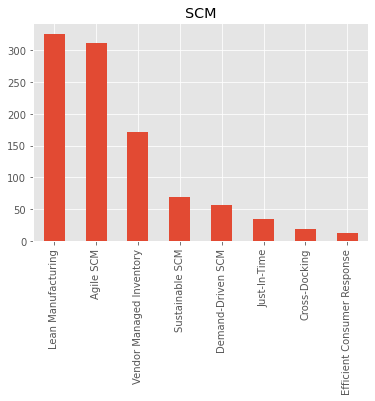

In [24]:
ax = df['SCM_Practices'].value_counts() \
    .plot(kind = 'bar' , title = 'SCM')

ax.set_xlabel('')
ax.set_ylabel('')



In [25]:
df["Company_Name"].value_counts()

Pep Boys           6
Tire Kingdom       5
NAPA Auto Parts    5
America's Tire     5
Tire Warehouse     5
                  ..
Celsa Group        1
Uralkali           1
GE Centricity      1
Multi-Mile         1
BYD                1
Name: Company_Name, Length: 777, dtype: int64



## EDA



In [26]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85


In [27]:
df["Country"].value_counts()

United States     562
China              99
India              56
Japan              53
Germany            27
Canada             26
United Kingdom     20
South Korea        17
Italy              17
Spain              11
Sweden             10
Taiwan             10
France             10
Russia              8
Switzerland         7
Australia           7
Brazil              6
Netherlands         5
Israel              4
Luxembourg          4
Finland             4
Singapore           3
UAE                 3
Mexico              2
Indonesia           2
Austria             2
Thailand            2
Ireland             2
Norway              2
Denmark             2
o                   1
Croatia             1
Argentina           1
Qatar               1
Belgium             1
Egypt               1
Chile               1
Turkey              1
Saudi Arabia        1
Kuwait              1
South Africa        1
New Zealand         1
Morocco             1
Ukraine             1
Iran                1
Name: Coun

In [28]:
a = df.groupby("SCM_Practices")[["Inventory_Turnover_Ratio"]].mean()
a.sort_values("Inventory_Turnover_Ratio")

#Method of SCM have any impact on inventory turnover ratio ?


,Inventory_Turnover_Ratio
SCM_Practices,
Demand-Driven SCM,5.566667
Sustainable SCM,5.900000
Vendor Managed Inventory,6.021637
Lean Manufacturing,6.243558
Agile SCM,6.434615
Just-In-Time,7.155882
Cross-Docking,9.216667
Efficient Consumer Response,10.025000


In [29]:
b = df.groupby("SCM_Practices")[["Customer_Satisfaction_(%)"]].mean()
b

,Customer_Satisfaction_(%)
SCM_Practices,
Agile SCM,89.262821
Cross-Docking,90.333333
Demand-Driven SCM,89.578947
Efficient Consumer Response,88.750000
Just-In-Time,90.000000
Lean Manufacturing,89.006135
Sustainable SCM,88.898551
Vendor Managed Inventory,89.286550


Is there any impact of technologies to order fulfillment rate ?

We can observe AI,Robotics,Blockchain have most percentage and then ERP, AI, Blockchain second 



In [30]:
c = df.groupby("Technology_Utilized")[["Order_Fulfillment_Rate_(%)"]].mean()
c

,Order_Fulfillment_Rate_(%)
Technology_Utilized,
"AI, Robotics, Blockchain",97.666667
"ERP, AI, Blockchain",92.269281
"ERP, AI, Robotics",88.789809
"ERP, JIT, Robotics",88.500000


In [31]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85


In [32]:
df.describe()
#inventory turn over  max value is 50, it is outlier it should be examined

,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supply_Chain_Resilience_Score,Supplier_Relationship_Score
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,6.332933,11.449449,91.734735,89.214214,3.275275,97.410410,87.151151,719.019019,83.450450,10.834835,8.954955,88.088088,83.882883
std,5.477182,4.204349,2.890920,2.265927,1.590711,1.169816,2.378969,271.875839,2.311706,1.950733,2.862054,2.858424,2.851589
min,1.000000,2.000000,87.000000,85.000000,1.000000,95.000000,80.000000,300.000000,75.000000,8.000000,3.000000,80.000000,78.000000
25%,4.500000,10.000000,90.000000,88.000000,2.000000,97.000000,85.000000,500.000000,81.000000,10.000000,8.000000,85.000000,80.000000
50%,5.500000,11.000000,91.000000,89.000000,3.000000,98.000000,88.000000,700.000000,85.000000,11.000000,10.000000,88.000000,85.000000
75%,6.200000,14.000000,93.000000,91.000000,4.000000,98.000000,88.000000,800.000000,85.000000,11.000000,10.000000,90.000000,85.000000
max,50.000000,22.000000,99.000000,94.000000,10.000000,99.000000,92.000000,1500.000000,90.000000,20.000000,15.000000,95.000000,90.000000


In [33]:
df[df["Inventory_Turnover_Ratio"] >=15]

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score
112,Sostram Corporation,Agricultural Biostimulants & Chemicals,United States,Lean Manufacturing,50.0,12,91,90,"ERP, AI, Blockchain",High,3,99,88,High,Low,700,85,11,10,High,88,85
128,"Hitachi Metals, Ltd.",Metals & Materials Manufacturing,Japan,Agile SCM,50.0,10,92,89,"ERP, AI, Blockchain",High,4,98,85,High,Medium,500,85,12,8,High,89,85
145,Yokohama Rubber,Tire Manufacturing,Japan,Lean Manufacturing,50.0,12,91,94,"ERP, AI, Blockchain",High,3,97,85,High,Medium,800,85,11,10,High,88,85
221,Volkswagen,Automotive Manufacturing,Germany,Vendor Managed Inventory,50.0,10,93,89,"ERP, AI, Blockchain",High,2,98,88,High,Medium,800,85,10,8,High,90,85
259,Goodyear Auto Service,Automotive Service & Tire Retail,United States,Lean Manufacturing,50.0,12,91,88,"ERP, AI, Blockchain",High,3,99,88,High,Low,700,85,11,10,High,88,85
296,Long Products Canada,Steel Manufacturing,Canada,Just-In-Time,50.0,7,98,90,"ERP, AI, Blockchain",High,1,98,90,High,High,1200,85,12,3,High,95,90
462,Westlake,Tire Manufacturing,China,Vendor Managed Inventory,50.0,10,93,89,"ERP, AI, Blockchain",High,2,98,88,High,Medium,800,85,10,8,High,90,85
630,Databricks,Data & AI Platform,United States,Agile SCM,50.0,7,99,94,"ERP, AI, Blockchain",High,2,98,92,High,Low,1200,88,15,3,High,95,90
642,Hill-Rom,Medical Devices & Hospital Beds,United States,Agile SCM,50.0,12,91,88,"ERP, AI, Blockchain",High,3,97,85,High,Medium,800,85,11,10,High,88,85
660,Lightning Motorcycles,Electric Motorcycle Manufacturing,United States,Lean Manufacturing,50.0,18,87,88,"ERP, AI, Robotics",Medium,6,95,85,Medium,Medium,500,80,9,15,Medium,85,80


Correlation Matrix


In [34]:
numeric_df = df.select_dtypes(include=[np.number])

In [35]:
correlation_matrix = numeric_df.corr()

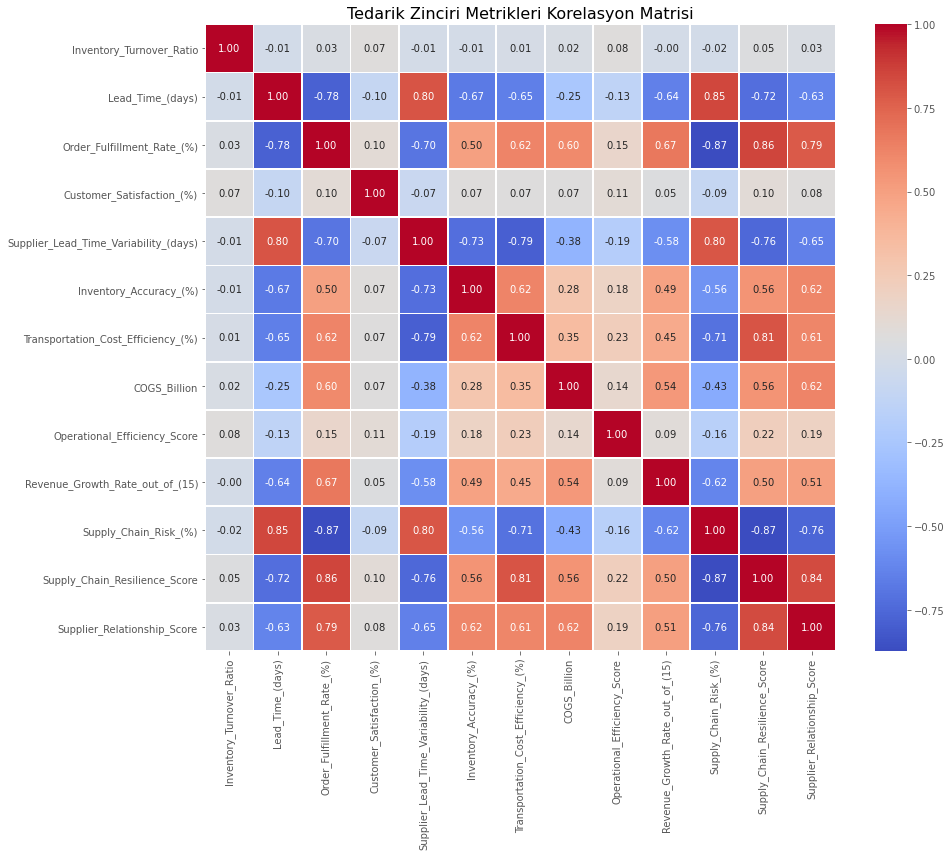

In [36]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Değerleri kutucuklar üzerine yaz
    fmt=".2f",           # 2 ondalık basamak kullan
    cmap='coolwarm',     # Renk paleti
    linewidths=.7,       # Kutucuklar arası çizgi
    cbar=True           # Renk çubuğunu göster
)
plt.title('Tedarik Zinciri Metrikleri Korelasyon Matrisi', fontsize=16)
plt.tight_layout()
plt.savefig('korelasyon_matrisi.png')
plt.show()

we created new column in int type  for examine the high resilience of companys

In [37]:
df['High_Resilience'] = (df['Supply_Chain_Resilience_Score'] >= df['Supply_Chain_Resilience_Score'].mean()).astype(int)
df[['Supply_Chain_Resilience_Score','High_Resilience']].head()

,Supply_Chain_Resilience_Score,High_Resilience
0,90,1
1,90,1
2,90,1
3,90,1
4,88,0


In [38]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0


In [39]:
mapping = { 'low' :1,
            'medium' :2,
              'high' :3 }

df['Complexity_Score'] = df['Supply_Chain_Complexity_Index'].str.lower().map(mapping)

In [40]:
df[['Supply_Chain_Complexity_Index', 'Complexity_Score']].head()

,Supply_Chain_Complexity_Index,Complexity_Score
0,High,3
1,High,3
2,High,3
3,High,3
4,Medium,2


In [41]:

df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience,Complexity_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0,2


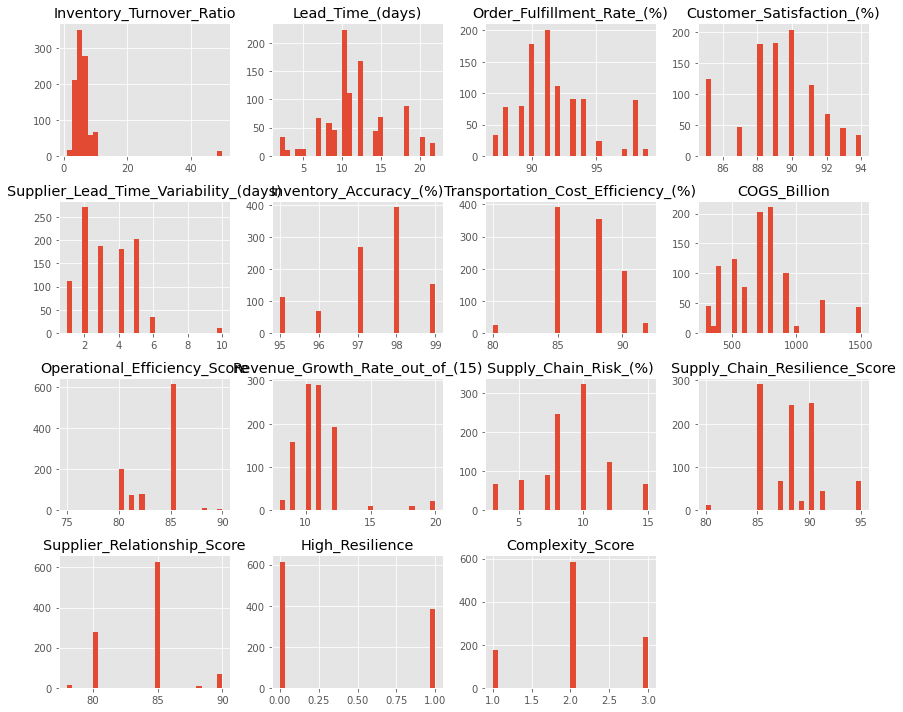

In [42]:
#Distribution of numeric columns

df.select_dtypes(include='number').hist(bins=30, figsize=(12,10))
plt.tight_layout()
plt.show()

In [43]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if not outliers.empty:
        print(f"{col}: outliers count = {len(outliers)}")

Inventory_Turnover_Ratio: outliers count = 97
Lead_Time_(days): outliers count = 66
Order_Fulfillment_Rate_(%): outliers count = 100
Supplier_Lead_Time_Variability_(days): outliers count = 12
Inventory_Accuracy_(%): outliers count = 113
Transportation_Cost_Efficiency_(%): outliers count = 24
COGS_Billion: outliers count = 44
Revenue_Growth_Rate_out_of_(15): outliers count = 68
Supply_Chain_Risk_(%): outliers count = 135
Complexity_Score: outliers count = 413


In [44]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience,Complexity_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0,2


In [45]:
df[["Country"]].value_counts()

Country       
United States     562
China              99
India              56
Japan              53
Germany            27
Canada             26
United Kingdom     20
Italy              17
South Korea        17
Spain              11
Sweden             10
Taiwan             10
France             10
Russia              8
Australia           7
Switzerland         7
Brazil              6
Netherlands         5
Israel              4
Luxembourg          4
Finland             4
Singapore           3
UAE                 3
Mexico              2
Ireland             2
Denmark             2
Indonesia           2
Thailand            2
Austria             2
Norway              2
Chile               1
Croatia             1
Egypt               1
Belgium             1
o                   1
Iran                1
Kuwait              1
Morocco             1
New Zealand         1
Qatar               1
Saudi Arabia        1
South Africa        1
Turkey              1
Ukraine             1
Argentina        

In [46]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience,Complexity_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0,2


In [47]:
df[["Country"]].value_counts()

Country       
United States     562
China              99
India              56
Japan              53
Germany            27
Canada             26
United Kingdom     20
Italy              17
South Korea        17
Spain              11
Sweden             10
Taiwan             10
France             10
Russia              8
Australia           7
Switzerland         7
Brazil              6
Netherlands         5
Israel              4
Luxembourg          4
Finland             4
Singapore           3
UAE                 3
Mexico              2
Ireland             2
Denmark             2
Indonesia           2
Thailand            2
Austria             2
Norway              2
Chile               1
Croatia             1
Egypt               1
Belgium             1
o                   1
Iran                1
Kuwait              1
Morocco             1
New Zealand         1
Qatar               1
Saudi Arabia        1
South Africa        1
Turkey              1
Ukraine             1
Argentina        

In [48]:
df["Country"].duplicated()

0      False
1       True
2       True
3       True
4      False
       ...  
994     True
995     True
996     True
997     True
998     True
Name: Country, Length: 999, dtype: bool

In [49]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience,Complexity_Score
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0,2


In [50]:
#convert to all strings lower capital

industry_col = df["Industry"].astype(str).str.lower().fillna('')


In [51]:
conditions = [
    
    # ÇELİK VE METALLER
    industry_col.str.contains('steel|metals|mining|alloy|iron|soil'),

    # OTOMOTİV, LASTİK VE TAŞIMACILIK
    industry_col.str.contains('automotive|tire|motorcycle|electric vehicle|mobility|supplier|commercial vehicle|truck'),

    # SAĞLIK VE İLAÇ (PHARMA, BIYOTEKNOLOJİ, CİHAZLAR, HCIT)
    industry_col.str.contains('pharma|biotech|medical|health|diagnostic|genomics|therapeutic'),

    # TEKNOLOJİ VE YAZILIM
    industry_col.str.contains('software|technology|semiconductor|data|cloud|analytics|computing|electronics|telecommunication|e-commerce|aı|intelligence'),

    # TARIM VE KİMYASALLAR
    industry_col.str.contains('fertilizer|chemical|agrochemicals|crop|agri|biostimulants|chemicals|seeds'),

    # PERAKENDE VE TÜKETİCİ ÜRÜNLERİ (FMCG)
    industry_col.str.contains('retail|consumer|food|beverage|warehouse|distribution'),

    # ENERJİ VE HAMMADDE
    industry_col.str.contains('oil|gas|energy|mining'),

    # ÇEŞİTLİ ENDÜSTRİ VE HOLDİNGLER
    industry_col.str.contains('conglomerate|industrial|engineering|association'),
]
    


In [52]:
choices = [
    'Steel & Metals',
    'Automotive & Transport',
    'Pharma & Healthtech',
    'Tech & Software',
    'Agri & Chemicals',
    'Retail & Consumer',
    'Energy & Mining',
    'Conglomerate/Other',
]


In [53]:
df["Industry_Categories"] = np.select(conditions, choices, default='Other/Services')

In [54]:
df[['Industry', 'Industry_Categories']].head(10)


,Industry,Industry_Categories
0,Social Media & Technology,Tech & Software
1,Software & Data Management,Tech & Software
2,Biotechnology & Genomics,Pharma & Healthtech
3,Healthcare Information Technology (HCIT),Pharma & Healthtech
4,Automotive Manufacturing (Luxury Sports Cars),Automotive & Transport
5,Automotive Manufacturing (Motorcycles/Scooters),Automotive & Transport
6,Automotive Safety Systems,Automotive & Transport
7,Tire Manufacturing,Automotive & Transport
8,Automotive Parts Retail & Distribution,Automotive & Transport
9,Automotive Repair & Parts Retail,Automotive & Transport


In [55]:
df = df[df["Company_Name"] != "Healthcare Companies (continued):"] 



In [56]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience,Complexity_Score,Industry_Categories
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3,Tech & Software
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3,Tech & Software
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3,Pharma & Healthtech
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,20,5,High,90,85,1,3,Pharma & Healthtech
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0,2,Automotive & Transport


In [57]:
kosul = df['Revenue_Growth_Rate_out_of_(15)'] > 15

df.loc[kosul, 'Revenue_Growth_Rate_out_of_(15)'] = 15


C:\Anaconda3\lib\site-packages\pandas\core\indexing.py:1765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [58]:
output_filename = 'Konsolide_SCM_Veri_Seti3.xlsx'

df.to_excel(
output_filename,
index = False,
sheet_name = "Organized Data"
)

In [59]:
df.head()

,Company_Name,Industry,Country,SCM_Practices,Inventory_Turnover_Ratio,Lead_Time_(days),Order_Fulfillment_Rate_(%),Customer_Satisfaction_(%),Technology_Utilized,Supply_Chain_Agility,Supplier_Lead_Time_Variability_(days),Inventory_Accuracy_(%),Transportation_Cost_Efficiency_(%),Supply_Chain_Integration_Level,Supply_Chain_Complexity_Index,COGS_Billion,Operational_Efficiency_Score,Revenue_Growth_Rate_out_of_(15),Supply_Chain_Risk_(%),Supplier_Collaboration_Level,Supply_Chain_Resilience_Score,Supplier_Relationship_Score,High_Resilience,Complexity_Score,Industry_Categories
0,Pinterest,Social Media & Technology,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,15,5,High,90,85,1,3,Tech & Software
1,Informatica,Software & Data Management,United States,Just-In-Time,8.2,2,98,92,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,15,5,High,90,85,1,3,Tech & Software
2,Illumina,Biotechnology & Genomics,United States,Just-In-Time,5.8,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,15,5,High,90,85,1,3,Pharma & Healthtech
3,Cerner,Healthcare Information Technology (HCIT),United States,Just-In-Time,5.5,2,98,89,"AI, Robotics, Blockchain",High,1,99,88,High,High,1500,85,15,5,High,90,85,1,3,Pharma & Healthtech
4,Ferrari,Automotive Manufacturing (Luxury Sports Cars),Italy,Agile SCM,6.0,10,92,85,"ERP, AI, Blockchain",High,2,97,85,High,Medium,800,85,11,8,High,88,85,0,2,Automotive & Transport


In [60]:
avgsat = df.groupby(["Industry_Categories" ,"SCM_Practices"])["Customer_Satisfaction_(%)"].mean()
avgsat

Industry_Categories     SCM_Practices              
Agri & Chemicals        Agile SCM                      89.351852
                        Cross-Docking                  89.000000
                        Demand-Driven SCM              89.666667
                        Efficient Consumer Response    91.500000
                        Just-In-Time                   89.571429
                        Lean Manufacturing             89.000000
                        Sustainable SCM                88.888889
                        Vendor Managed Inventory       89.793103
Automotive & Transport  Agile SCM                      89.073770
                        Cross-Docking                  90.857143
                        Demand-Driven SCM              89.681818
                        Efficient Consumer Response    88.250000
                        Just-In-Time                   90.571429
                        Lean Manufacturing             89.056000
                        Sustainable SC

In [61]:
avgsat.describe()

count    43.000000
mean     89.203579
std       1.261334
min      85.000000
25%      88.873016
50%      89.176471
75%      89.803959
max      91.666667
Name: Customer_Satisfaction_(%), dtype: float64

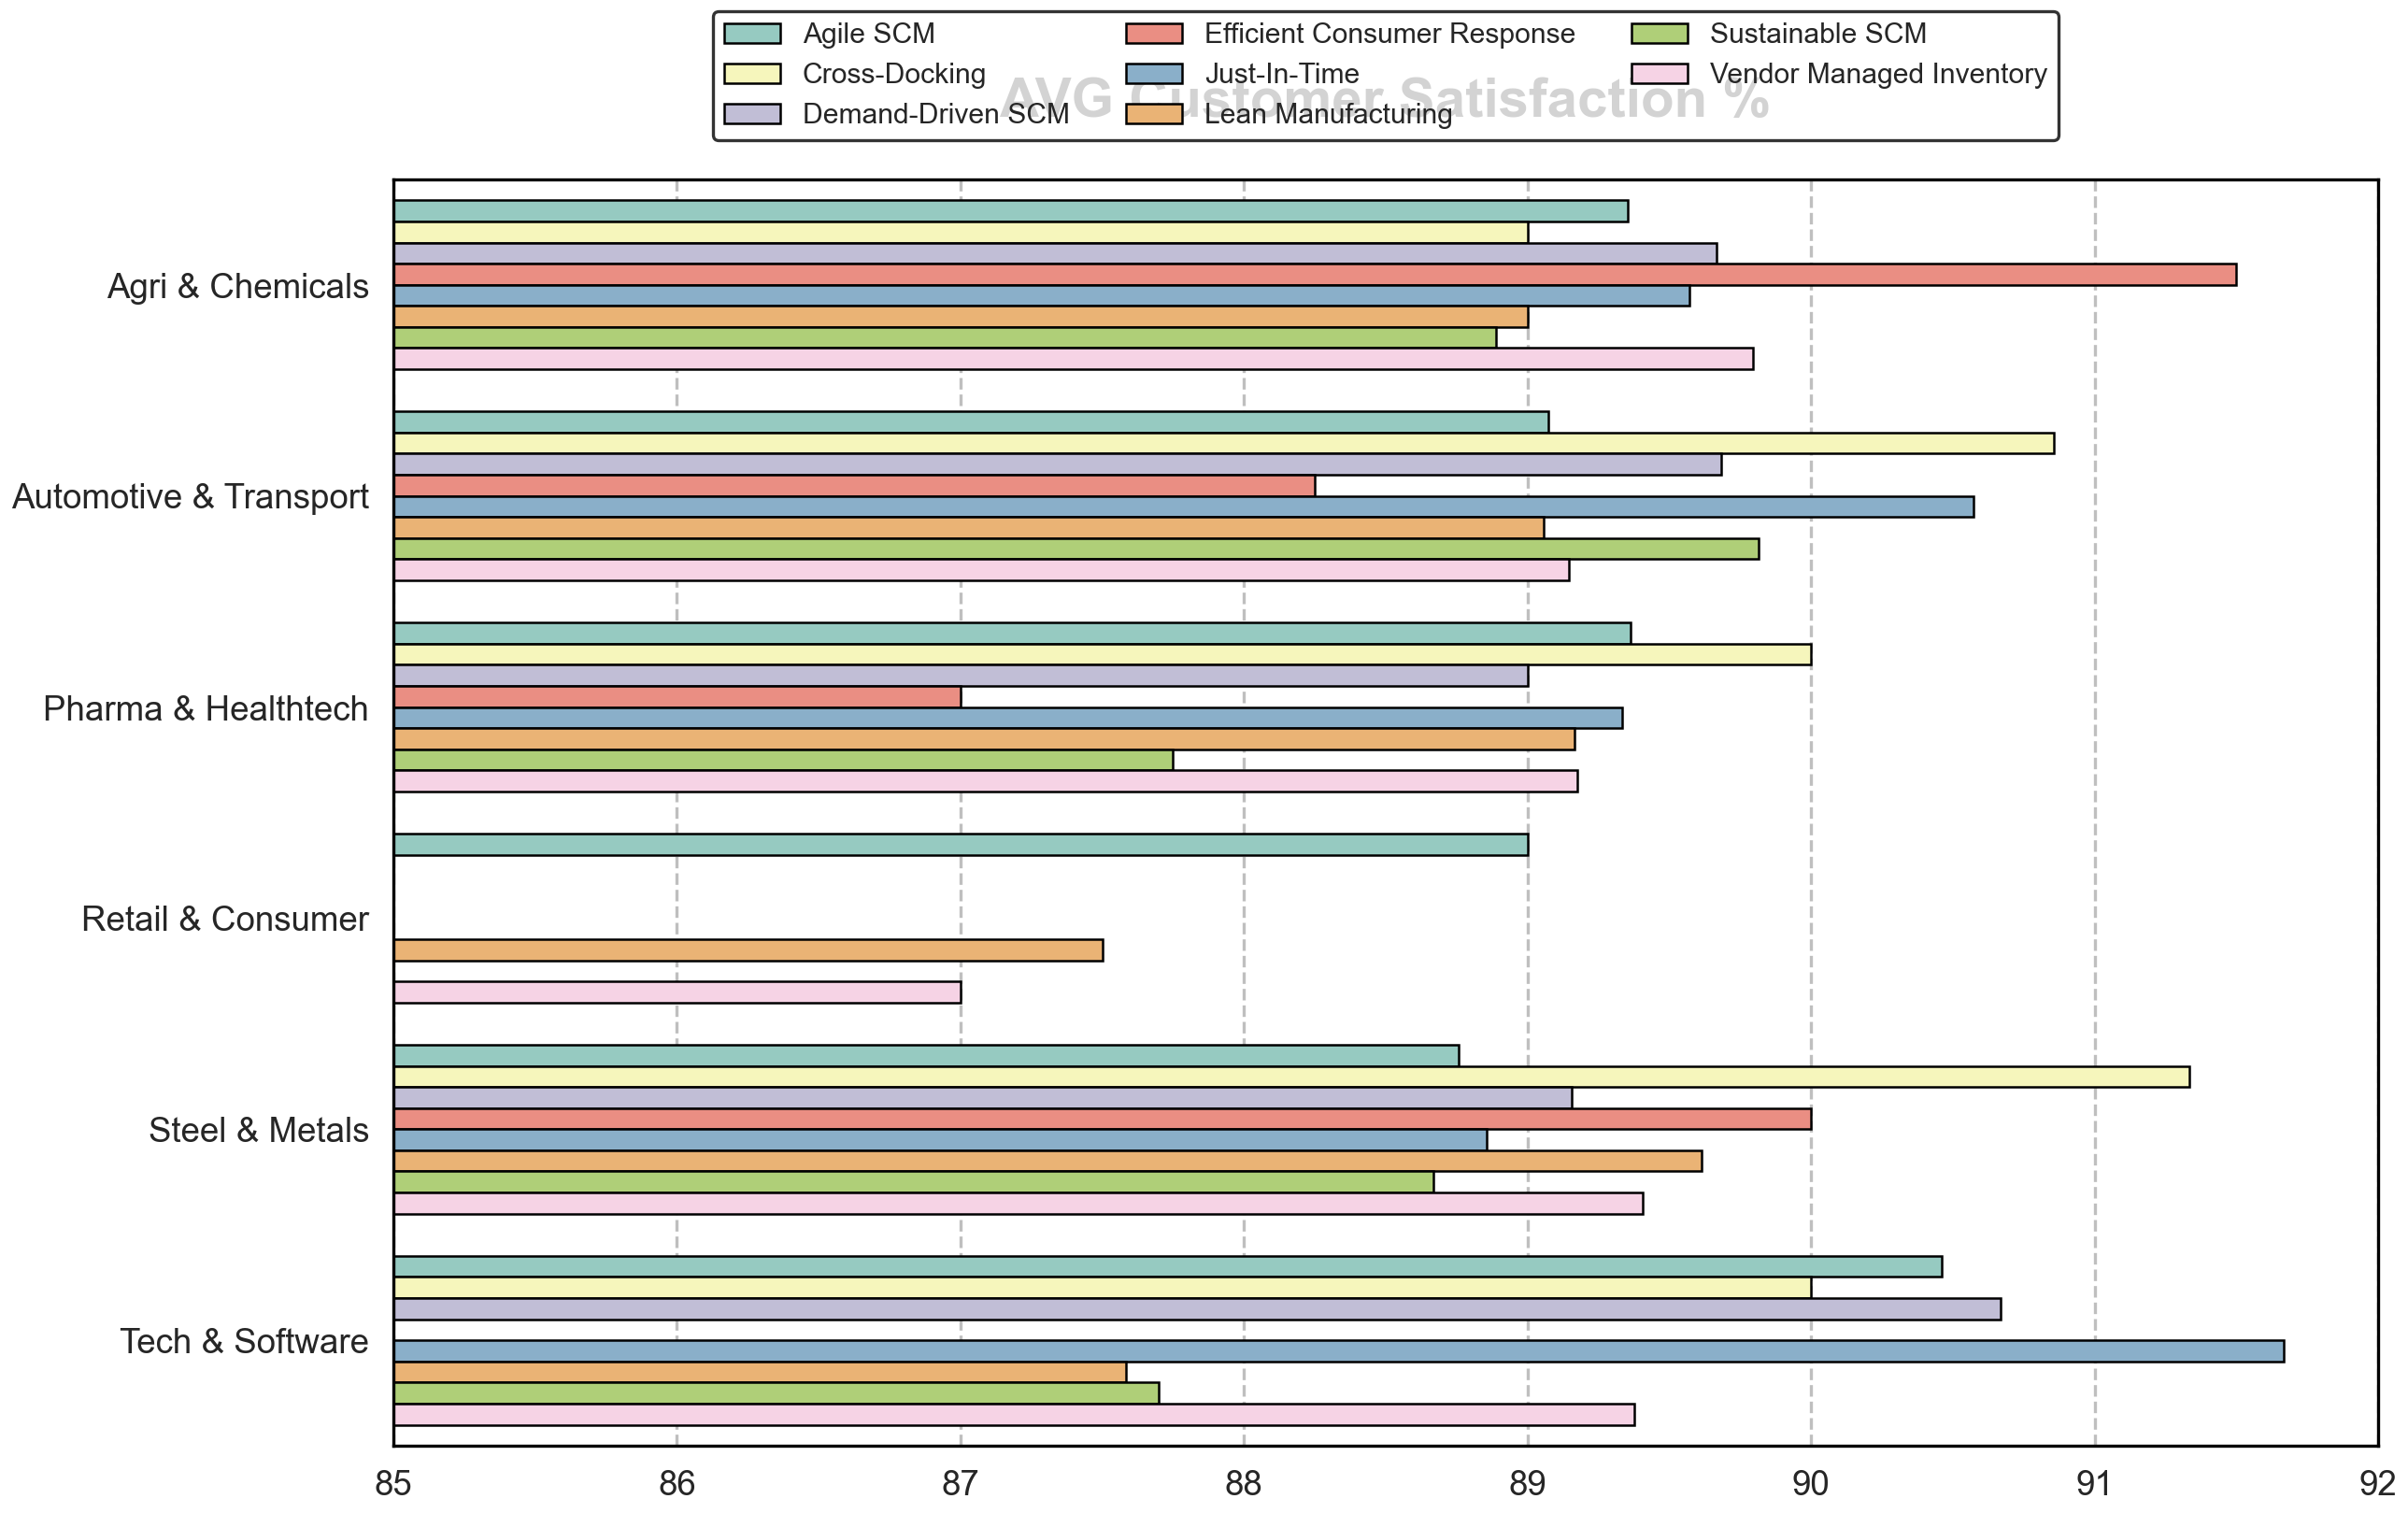

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Stil ve Bağlam Ayarları (Beyaz arka plan ve büyük fontlar için)
sns.set_style("white") 
sns.set_context("poster") # Her şeyi otomatik olarak sunum boyutuna getirir

# 2. Ortalamaları hesapla ve filtrele (Senin mantığın aynı kalıyor)
avgsat = df.groupby(["Industry_Categories", "SCM_Practices"])["Customer_Satisfaction_(%)"].mean()
mask = (avgsat >= 85) & (avgsat <= 92)
avgsat_filtered = avgsat[mask].reset_index()

# 3. Grafik oluşturma (Boyutu biraz daha dikey yapıyoruz ki sektörler rahat sığsın)
plt.figure(figsize=(22, 14), dpi=120)

# ÖNEMLİ: Yatay grafik için x ve y yer değiştirdi!
ax = sns.barplot(data=avgsat_filtered, 
            x='Customer_Satisfaction_(%)',  # Puanlar X eksenine
            y='Industry_Categories',        # Sektörler Y eksenine (Yatay durması için)
            hue='SCM_Practices',
            palette="Set3",
            edgecolor="black",
            linewidth=1.5)

# 4. Eksen Sınırları (Yatay grafik olduğu için artık plt.xlim kullanıyoruz)
plt.xlim(85, 92) 

# 5. Eksen ve Çerçeve Temizliği
plt.xlabel(None)
plt.ylabel(None)
plt.title('AVG Customer Satisfaction %', fontsize=35, pad=40, fontweight='bold')

# Değerlerin (fontların) boyutunu ayarla
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Grafiğin etrafındaki siyah çerçeveyi kalınlaştır (Senin görseldeki gibi net durması için)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 6. Izgara Çizgileri (Görseldeki gibi dikey hafif çizgiler ekleyelim)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True) # Izgara çizgilerini barların arkasına atar

# 7. Lejant (Legend) Ayarı - Üst orta boşluğa
plt.legend(
    fontsize=18,
    bbox_to_anchor=(0.5, 1.02), # Grafiğin hemen üzerine ortalar
    loc='lower center',
    ncol=3,                     # 3'lü sütun yaparak alanı genişletir
    frameon=True,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

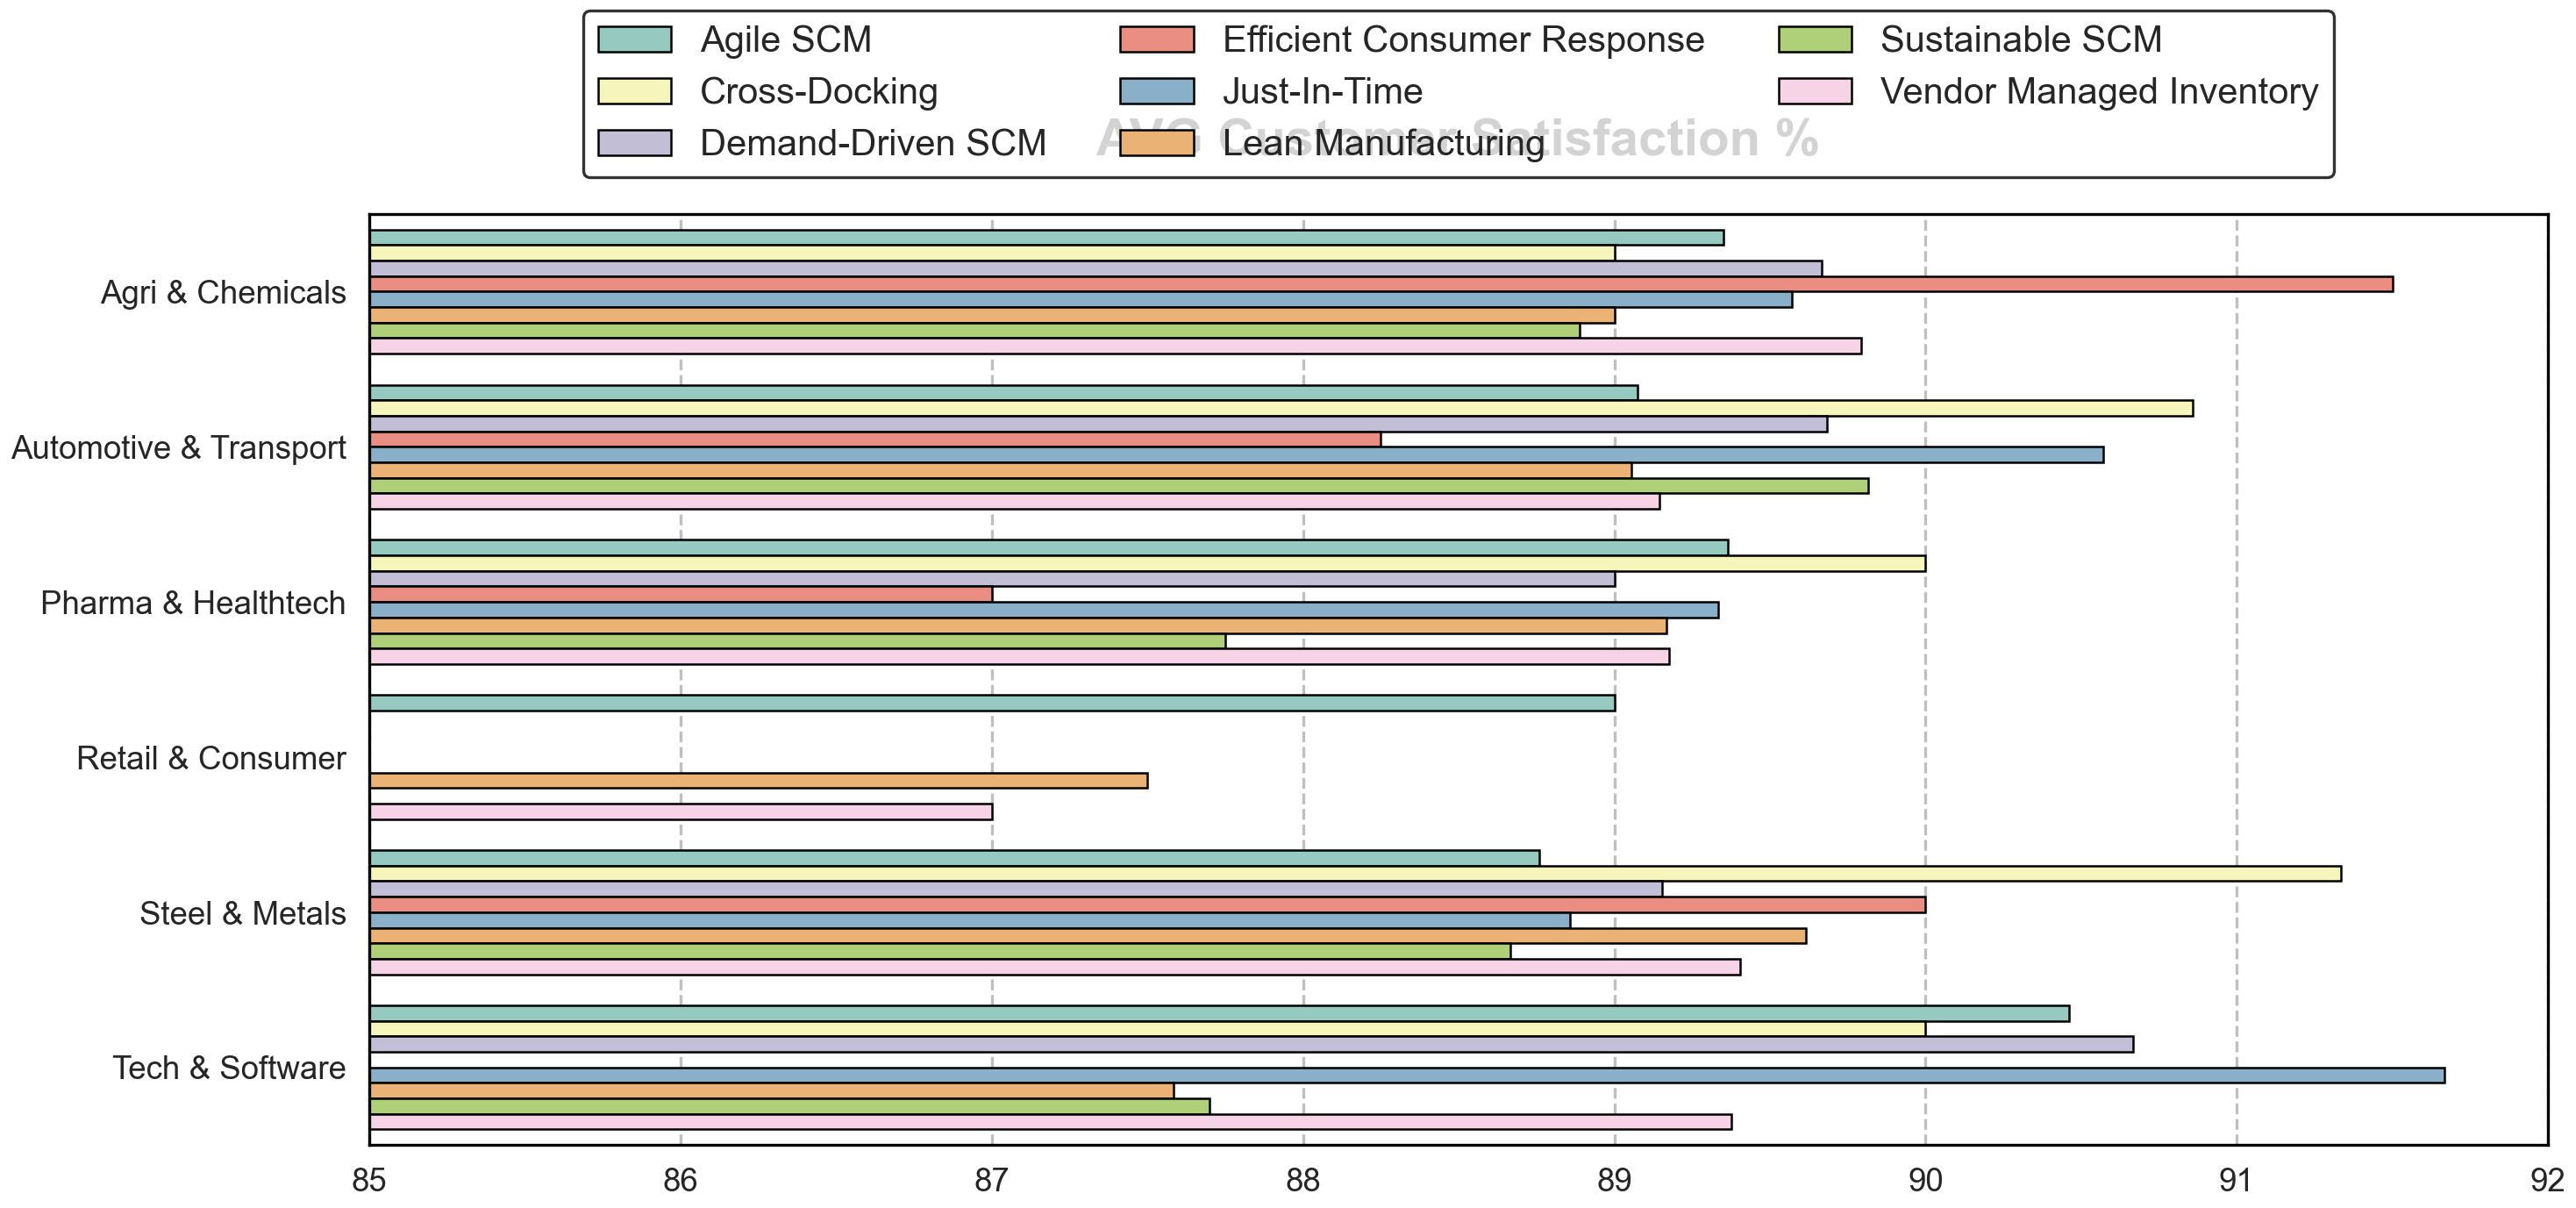

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Stil ve Bağlam Ayarları (Beyaz arka plan ve büyük fontlar için)
sns.set_style("white") 
sns.set_context("poster") # Her şeyi otomatik olarak sunum boyutuna getirir

# 2. Ortalamaları hesapla ve filtrele (Senin mantığın aynı kalıyor)
avgsat = df.groupby(["Industry_Categories", "SCM_Practices"])["Customer_Satisfaction_(%)"].mean()
mask = (avgsat >= 85) & (avgsat <= 92)
avgsat_filtered = avgsat[mask].reset_index()

# 3. Grafik oluşturma (Boyutu biraz daha dikey yapıyoruz ki sektörler rahat sığsın)
plt.figure(figsize=(25, 12), dpi=120)

# ÖNEMLİ: Yatay grafik için x ve y yer değiştirdi!
ax = sns.barplot(data=avgsat_filtered, 
            x='Customer_Satisfaction_(%)',  # Puanlar X eksenine
            y='Industry_Categories',        # Sektörler Y eksenine (Yatay durması için)
            hue='SCM_Practices',
            palette="Set3",
            edgecolor="black",
            linewidth=1.5)



# 4. Eksen Sınırları (Yatay grafik olduğu için artık plt.xlim kullanıyoruz)
plt.xlim(85, 92) 

# 5. Eksen ve Çerçeve Temizliği
plt.xlabel(None)
plt.ylabel(None)
plt.title('AVG Customer Satisfaction %', fontsize=35, pad=40, fontweight='bold')

# Değerlerin (fontların) boyutunu ayarla
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Grafiğin etrafındaki siyah çerçeveyi kalınlaştır (Senin görseldeki gibi net durması için)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 6. Izgara Çizgileri (Görseldeki gibi dikey hafif çizgiler ekleyelim)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True) # Izgara çizgilerini barların arkasına atar

# 7. Lejant (Legend) Ayarı - Üst orta boşluğa
plt.legend(
    fontsize=25,
    bbox_to_anchor=(0.5, 1.02), # Grafiğin hemen üzerine ortalar
    loc='lower center',
    ncol=3,                     # 3'lü sütun yaparak alanı genişletir
    frameon=True,
    edgecolor="black"
)

plt.tight_layout()
plt.show()